In [1]:
# If needed, run this cell once:
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
FILE_PATH = "btc_4h_data_2018_to_2025.csv"

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (17958, 12)


,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 00:00:00.000000,13715.65,13715.65,13155.38,13410.03,1676.204807,2018-01-01 03:59:59.999000,2.251607e+07,19438,739.518666,9.937537e+06,0
1,2018-01-01 04:00:00.000000,13434.98,13818.55,13322.15,13570.35,1302.214836,2018-01-01 07:59:59.999000,1.770254e+07,18061,588.516222,7.998796e+06,0
2,2018-01-01 08:00:00.000000,13569.98,13735.24,13001.13,13220.56,1319.755931,2018-01-01 11:59:59.999000,1.765121e+07,17200,582.668293,7.792109e+06,0
3,2018-01-01 12:00:00.000000,13220.56,13330.00,12750.00,13247.00,1831.933153,2018-01-01 15:59:59.999000,2.391259e+07,21357,830.314747,1.083304e+07,0
4,2018-01-01 16:00:00.000000,13247.00,13290.65,12940.00,13240.37,1092.337234,2018-01-01 19:59:59.999000,1.434887e+07,13178,557.453779,7.324320e+06,0


<class 'pandas.DataFrame'>
RangeIndex: 17958 entries, 0 to 17957
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Open time                     17958 non-null  str    
 1   Open                          17958 non-null  float64
 2   High                          17958 non-null  float64
 3   Low                           17958 non-null  float64
 4   Close                         17958 non-null  float64
 5   Volume                        17958 non-null  float64
 6   Close time                    17958 non-null  str    
 7   Quote asset volume            17958 non-null  float64
 8   Number of trades              17958 non-null  int64  
 9   Taker buy base asset volume   17958 non-null  float64
 10  Taker buy quote asset volume  17958 non-null  float64
 11  Ignore                        17958 non-null  int64  
dtypes: float64(8), int64(2), str(2)
memory usage: 2.6 MB


None

In [3]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore']


In [4]:
possible_date_cols = [
    "date",
    "datetime",
    "timestamp",
    "time",
    "open_time",
    "close_time"
]

date_col = None

for col in possible_date_cols:
    if col in df.columns:
        date_col = col
        break

if date_col:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values(date_col).reset_index(drop=True)
    print("Date column:", date_col)
else:
    print("No standard date column detected.")

Date column: open_time


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)

display(
    missing[missing > 0].to_frame("missing_values")
)

# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after cleaning:", df.shape)

,missing_values


Dataset shape after cleaning: (17958, 12)


In [6]:
# Try to find standard OHLCV columns
column_aliases = {
    "open": ["open", "opening_price"],
    "high": ["high", "high_price"],
    "low": ["low", "low_price"],
    "close": ["close", "closing_price"],
    "volume": ["volume", "vol", "base_volume"]
}

detected = {}

for standard_name, candidates in column_aliases.items():
    for candidate in candidates:
        if candidate in df.columns:
            detected[standard_name] = candidate
            break

print("Detected columns:")
print(detected)

Detected columns:
{'open': 'open', 'high': 'high', 'low': 'low', 'close': 'close', 'volume': 'volume'}


In [7]:
required = ["open", "high", "low", "close"]

missing_required = [
    col for col in required
    if col not in detected
]

if missing_required:
    raise ValueError(
        f"Missing required BTC columns: {missing_required}"
    )

open_col = detected["open"]
high_col = detected["high"]
low_col = detected["low"]
close_col = detected["close"]

df["return_4h"] = df[close_col].pct_change()

df["log_return"] = np.log(
    df[close_col] / df[close_col].shift(1)
)

df["volatility_24h"] = (
    df["return_4h"]
    .rolling(6)
    .std()
)

df["volatility_7d"] = (
    df["return_4h"]
    .rolling(42)
    .std()
)

df["price_range"] = (
    df[high_col] - df[low_col]
) / df[close_col]

df["body_size"] = (
    df[close_col] - df[open_col]
) / df[open_col]

df["momentum_24h"] = (
    df[close_col].pct_change(6)
)

df["momentum_7d"] = (
    df[close_col].pct_change(42)
)

# Moving averages
df["sma_24h"] = df[close_col].rolling(6).mean()
df["sma_7d"] = df[close_col].rolling(42).mean()

df["price_vs_sma_7d"] = (
    df[close_col] / df["sma_7d"] - 1
)

# Volume features if volume exists
if "volume" in detected:
    volume_col = detected["volume"]

    df["volume_change"] = (
        df[volume_col].pct_change()
    )

    df["volume_sma_7d"] = (
        df[volume_col].rolling(42).mean()
    )

    df["relative_volume"] = (
        df[volume_col] / df["volume_sma_7d"]
    )

display(df.tail())

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore,return_4h,log_return,volatility_24h,volatility_7d,price_range,body_size,momentum_24h,momentum_7d,sma_24h,sma_7d,price_vs_sma_7d,volume_change,volume_sma_7d,relative_volume
17953,2026-03-14 20:00:00,70699.99,71253.17,70650.09,71211.95,854.74443,2026-03-14 23:59:59.999000,6.064695e+07,218856,460.87399,3.270964e+07,0,0.007241,0.007215,0.004782,0.008655,0.008469,0.007241,0.003975,0.058711,70820.240000,69702.234048,0.021660,0.244295,4317.934230,0.197952
17954,2026-03-15 00:00:00,71211.95,71634.08,70858.82,71363.14,2591.56425,2026-03-15 03:59:59.999000,1.846720e+08,358161,1325.18262,9.446511e+07,0,0.002123,0.002121,0.004781,0.008614,0.010864,0.002123,0.003965,0.065117,70867.213333,69806.112143,0.022305,2.031976,4310.984818,0.601154
17955,2026-03-15 04:00:00,71363.13,71800.68,71330.66,71453.59,2377.69395,2026-03-15 07:59:59.999000,1.701599e+08,294463,1357.70967,9.718199e+07,0,0.001267,0.001267,0.003089,0.008599,0.006578,0.001268,0.012138,0.061404,71010.031667,69904.533095,0.022160,-0.082526,4299.356150,0.553035
17956,2026-03-15 08:00:00,71453.59,71940.49,71453.59,71839.42,2170.14550,2026-03-15 11:59:59.999000,1.557364e+08,310575,1126.70208,8.085256e+07,0,0.005400,0.005385,0.003388,0.008618,0.006778,0.005400,0.015378,0.064051,71191.365000,70007.495476,0.026168,-0.087290,4272.373798,0.507948
17957,2026-03-15 12:00:00,71839.41,71839.42,71263.99,71481.24,2095.34940,2026-03-15 15:59:59.999000,1.498360e+08,362063,877.38863,6.273704e+07,0,-0.004986,-0.004998,0.004204,0.008629,0.008050,-0.004986,0.012768,0.063420,71341.556667,70108.995714,0.019573,-0.034466,4215.965832,0.497003


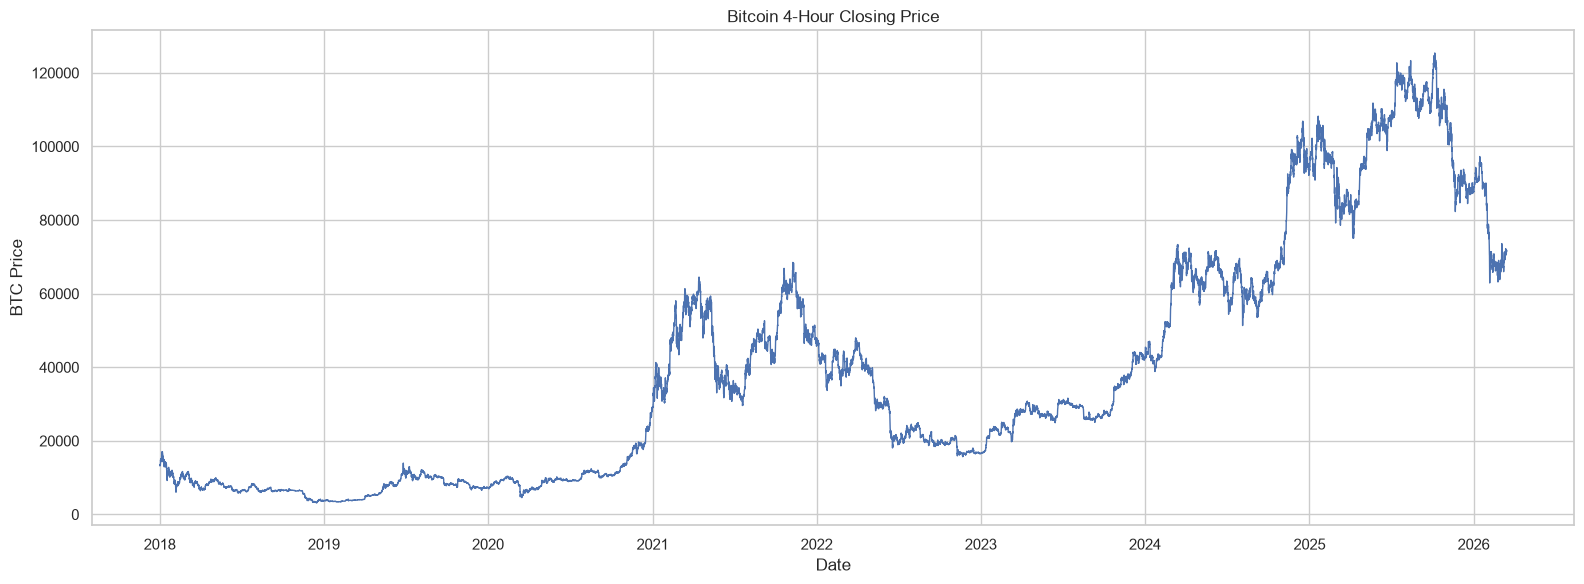

In [8]:
plt.figure(figsize=(16, 6))

plt.plot(
    df[date_col],
    df[close_col],
    linewidth=1
)

plt.title("Bitcoin 4-Hour Closing Price")
plt.xlabel("Date")
plt.ylabel("BTC Price")

plt.tight_layout()
plt.show()

In [9]:
features = [
    "return_4h",
    "volatility_24h",
    "volatility_7d",
    "price_range",
    "body_size",
    "momentum_24h",
    "momentum_7d",
    "price_vs_sma_7d"
]

if "relative_volume" in df.columns:
    features.append("relative_volume")

cluster_df = df[features].copy()

# Replace infinite values
cluster_df = cluster_df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Remove rows containing missing feature values
valid_index = cluster_df.dropna().index

cluster_df = cluster_df.loc[valid_index]

print("Features used for K-Means:")
print(features)

print("\nRows available for clustering:", len(cluster_df))

Features used for K-Means:
['return_4h', 'volatility_24h', 'volatility_7d', 'price_range', 'body_size', 'momentum_24h', 'momentum_7d', 'price_vs_sma_7d', 'relative_volume']

Rows available for clustering: 17916


In [10]:
OUTPUT_FILE = "btc_4h_kmeans_nlp_processed.csv"

df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"Saved processed dataset to: {OUTPUT_FILE}")

Saved processed dataset to: btc_4h_kmeans_nlp_processed.csv
